In [30]:
# ============================================
# Standard library imports
# ============================================

import sys
import re
import ast
import logging
import warnings
from pathlib import Path

from IPython.display import display

warnings.filterwarnings("ignore")


# ============================================
# Numeric / statistics
# ============================================

import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import spearmanr, pearsonr


# ============================================
# Plotting / visualization
# ============================================

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec

import seaborn as sns


# ============================================
# Version info
# ============================================

print(f"python  = {sys.version_info[0]}.{sys.version_info[1]}.{sys.version_info[2]}")
print(f"pandas  = {pd.__version__}")
print(f"numpy   = {np.__version__}")
print(f"scipy   = {scipy.__version__}")


# ============================================
# Logging
# ============================================

logging.root.handlers = []

stream_handler = logging.StreamHandler(sys.stderr)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)8s: %(message)s",
    handlers=[stream_handler],
)

logger = logging.getLogger(__name__)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

python  = 3.11.15
pandas  = 2.3.3
numpy   = 2.4.6
scipy   = 1.17.1


In [18]:
# ============================================
# Analysis configuration
# ============================================

RESULT_DIR = Path("../results")
FIGURE_DIR = RESULT_DIR / "figures"
TABLE_DIR = RESULT_DIR / "table"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SPECIES_LIST = ["AT21", "NB21", "OS21"]

MODEL_INFO = {
    "lgbm": {
        "label": "LightGBM",
        "dir": RESULT_DIR / "lgbm",
        "color": "#913535FF",
    },
    "rf": {
        "label": "Random Forest",
        "dir": RESULT_DIR / "rf",
        "color": "#134956",
    },
}

DATASET_ORDER = ["Training", "Test"]

print("RESULT_DIR:", RESULT_DIR.resolve())
print("FIGURE_DIR:", FIGURE_DIR.resolve())
print("TABLE_DIR :", TABLE_DIR.resolve())

RESULT_DIR: /home/ha-ibnu/Code/regression/results
FIGURE_DIR: /home/ha-ibnu/Code/regression/results/figures
TABLE_DIR : /home/ha-ibnu/Code/regression/results/table


In [19]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 6.0,
    "dpi": 300,
}


SPECIES_INFO = {
    "AT21": {
        "label": "AT",
        "short": "AT21",
        "color": "#664D0AFF",
        "marker": "o",
    },
    "NB21": {
        "label": "NB",
        "short": "NB21",
        "color": "#7e3131",
        "marker": "^",
    },
    "OS21": {
        "label": "OS",
        "short": "OS21",
        "color": "#13563f",
        "marker": "s",
    },
}

def set_plot_style(
    *,
    base_fontsize=12,
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=12,
    dpi=300,
    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,
    tick_size_major=6,
    tick_dir="out",
    grid=False,
    fig_w=6.0,
    fig_h=6.0,
):
    sns.set_style("ticks")

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        "legend.frameon": False,

        "savefig.bbox": "tight",
        "savefig.transparent": False,
        "figure.autolayout": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(w=None, h=None, dpi=None):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


def _compact_formatter():
    def _fmt(x, _pos=None):
        axx = abs(x)

        if axx >= 1e9:
            s = f"{x / 1e9:.1f}B"
        elif axx >= 1e6:
            s = f"{x / 1e6:.1f}M"
        elif axx >= 1e3:
            s = f"{x / 1e3:.1f}k"
        else:
            s = f"{x:.2g}"

        return (
            s.replace(".0B", "B")
             .replace(".0M", "M")
             .replace(".0k", "k")
        )

    return FuncFormatter(_fmt)


def format_axis(
    ax,
    *,
    xlabel=None,
    ylabel=None,
    compact_ticks=(),
):
    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    fmt = _compact_formatter()

    if "x" in compact_ticks:
        ax.xaxis.set_major_formatter(fmt)

    if "y" in compact_ticks:
        ax.yaxis.set_major_formatter(fmt)

    return ax


# ============================================
# Joint scatter with KDE marginals
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return stats.spearmanr(x, y)

def _kde_1d(values, lo, hi, num=256):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    grid = np.linspace(lo, hi, num)

    if len(values) < 2:
        return grid, np.zeros_like(grid)

    try:
        kde = stats.gaussian_kde(values)
        dens = kde(grid)
        dens /= dens.max() if dens.max() > 0 else 1
        return grid, dens

    except Exception:
        return grid, np.zeros_like(grid)


def joint_scatter(
    x,
    y,
    *,
    color=None,
    point_size=18,
    alpha=0.65,
    show_identity=True,
    show_regression=True,
    annotate=True,
    annotate_spearman=True,
    xlabel=None,
    ylabel=None,
    title=None,
    figsize=None,
    w=None,
    h=None,
    dpi=None,
    annotate_fontsize=14,
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    n = len(x)

    if figsize is not None:
        FW, FH = figsize
    else:
        FW = float(w) if w is not None else _PLOT_CFG["fig_w"]
        FH = float(h) if h is not None else _PLOT_CFG["fig_h"]

    fig = plt.figure(
        figsize=(FW, FH),
        dpi=(dpi or _PLOT_CFG["dpi"]),
    )

    gs = GridSpec(
        2,
        2,
        width_ratios=(4, 1),
        height_ratios=(1, 4),
        hspace=0.05,
        wspace=0.05,
    )

    ax_top = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_joint)

    ax_joint.scatter(
        x,
        y,
        s=point_size,
        alpha=alpha,
        edgecolor="none",
        color=color,
    )

    lo = float(np.nanmin([x.min(), y.min()]))
    hi = float(np.nanmax([x.max(), y.max()]))

    pad = 0.05 * (hi - lo if hi > lo else 1.0)

    lo -= pad
    hi += pad

    ax_joint.set_xlim(lo, hi)
    ax_joint.set_ylim(lo, hi)

    if show_identity:
        ax_joint.plot(
            [lo, hi],
            [lo, hi],
            ls="--",
            lw=1.2,
            color="0.65",
            zorder=1,
        )

    if show_regression and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        slope, intercept = np.polyfit(x, y, 1)

        ax_joint.plot(
            [lo, hi],
            slope * np.array([lo, hi]) + intercept,
            color="black",
            lw=1.5,
            zorder=2,
        )

    format_axis(
        ax_joint,
        xlabel=xlabel,
        ylabel=ylabel,
        compact_ticks=(),
    )

    if title:
        ax_joint.set_title(title)

    if annotate and n >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rp, _ = safe_pearsonr(x, y)
        rs, _ = safe_spearmanr(x, y)

        txt = rf"$r_p = {rp:.2f}$"

        if annotate_spearman:
            txt += "\n" + rf"$r_s = {rs:.2f}$"

        txt += f"\n$n = {n}$"

        ax_joint.text(
            0.04,
            0.96,
            txt,
            transform=ax_joint.transAxes,
            ha="left",
            va="top",
            fontsize=annotate_fontsize,
        )

    gx, dx = _kde_1d(x, lo, hi)
    gy, dy = _kde_1d(y, lo, hi)

    ax_top.plot(gx, dx, lw=2, color=color)
    ax_top.axis("off")

    ax_right.plot(dy, gy, lw=2, color=color)
    ax_right.axis("off")

    plt.tight_layout()

    return fig, (ax_joint, ax_top, ax_right)


set_plot_style()

In [20]:
# ============================================
# Statistical helper functions
# ============================================

def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return pearsonr(x, y)


def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return np.nan, np.nan

    if np.std(x) == 0 or np.std(y) == 0:
        return np.nan, np.nan

    return spearmanr(x, y)


def summarize_numeric(df, group_cols, value_col):
    return (
        df
        .groupby(group_cols, dropna=False)[value_col]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .reset_index()
    )

In [21]:
# ============================================
# Load saved Step 1 result tables
# ============================================

def load_result_table(model_key, suffix):
    model_dir = MODEL_INFO[model_key]["dir"]
    rows = []

    for species in SPECIES_LIST:
        file = model_dir / f"{species}.{model_key}.{suffix}.tsv"

        if not file.exists():
            logger.warning("Missing file: %s", file)
            continue

        df = pd.read_csv(file, sep="\t")
        rows.append(df)

    if len(rows) == 0:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


metrics_df = pd.concat([
    load_result_table("lgbm", "metrics"),
    load_result_table("rf", "metrics"),
], ignore_index=True)

best_params_df = pd.concat([
    load_result_table("lgbm", "best_params"),
    load_result_table("rf", "best_params"),
], ignore_index=True)

feature_importance_df = pd.concat([
    load_result_table("lgbm", "feature_importance"),
    load_result_table("rf", "feature_importance"),
], ignore_index=True)

shap_summary_df = pd.concat([
    load_result_table("lgbm", "shap_summary"),
    load_result_table("rf", "shap_summary"),
], ignore_index=True)

cv_region_df = pd.concat([
    load_result_table("lgbm", "cv_by_region"),
    load_result_table("rf", "cv_by_region"),
], ignore_index=True)

cv_feature_type_df = pd.concat([
    load_result_table("lgbm", "cv_by_feature_type"),
    load_result_table("rf", "cv_by_feature_type"),
], ignore_index=True)

prediction_df = pd.concat([
    load_result_table("lgbm", "predictions"),
    load_result_table("rf", "predictions"),
], ignore_index=True)

# ============================================
# Quick sanity check
# ============================================

tables = {
    "metrics": metrics_df,
    "best_params": best_params_df,
    "feature_importance": feature_importance_df,
    "shap_summary": shap_summary_df,
    "cv_region": cv_region_df,
    "cv_feature_type": cv_feature_type_df,
    "prediction": prediction_df,
}

for name, df in tables.items():
    print(f"{name:20s}: {df.shape}")

display(metrics_df.head())
display(prediction_df.head())

metrics             : (12, 22)
best_params         : (6, 14)
feature_importance  : (2156, 5)
shap_summary        : (2254, 7)
cv_region           : (90, 9)
cv_feature_type     : (1530, 9)
prediction          : (36118, 10)


,species,model,dataset,R2,Pearson_r,RMSE,MAE,best_cv_R2,n_train,n_test,...,k_cv,n_estimators,learning_rate,best_param.max_depth,best_param.min_child_samples,best_param.feature_fraction,best_param.num_leaves,best_param.min_samples_leaf,best_param.min_samples_split,best_param.max_features
0,AT21,LightGBM,Training,0.556015,0.771511,0.666322,0.511277,0.252106,5698,1428,...,10,100,0.05,7,30.0,0.3,58.0,NaN,NaN,NaN
1,AT21,LightGBM,Test,0.298263,0.548332,0.842763,0.643657,0.252106,5698,1428,...,10,100,0.05,7,30.0,0.3,58.0,NaN,NaN,NaN
2,NB21,LightGBM,Training,0.590997,0.789585,0.639533,0.490118,0.310320,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
3,NB21,LightGBM,Test,0.291868,0.542054,0.857198,0.649158,0.310320,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
4,OS21,LightGBM,Training,0.717678,0.871608,0.531340,0.408141,0.364618,4445,1107,...,10,100,0.05,7,3.0,0.5,56.0,NaN,NaN,NaN


,species,model,var_id,trans_id,gene_id,dataset,observed,predicted,residual,abs_residual
0,AT21,LightGBM,AT5G05370.1.1591901.1590815,AT5G05370.1,AT5G05370,Training,0.054841,0.466496,-0.411655,NaN
1,AT21,LightGBM,AT5G16060.1.5246121.5247413,AT5G16060.1,AT5G16060,Training,-1.094430,-0.364117,-0.730313,NaN
2,AT21,LightGBM,AT2G34160.1.14426246.14427367,AT2G34160.1,AT2G34160,Training,-0.073162,-0.028276,-0.044886,NaN
3,AT21,LightGBM,AT5G54600.1.22183004.22184509,AT5G54600.1,AT5G54600,Training,-0.302488,-0.468002,0.165514,NaN
4,AT21,LightGBM,AT2G23340.1.9937988.9938873,AT2G23340.1,AT2G23340,Training,1.491571,0.321837,1.169734,NaN


In [22]:
# ============================================
# EDA inventory of loaded result tables
# ============================================

for name, df in tables.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print()

    if "species" in df.columns:
        print("Species:")
        print(df["species"].value_counts(dropna=False))
        print()

    if "model" in df.columns:
        print("Models:")
        print(df["model"].value_counts(dropna=False))
        print()

    if "dataset" in df.columns:
        print("Datasets:")
        print(df["dataset"].value_counts(dropna=False))
        print()

    display(df.head())

metrics
Shape: (12, 22)
Columns:
['species', 'model', 'dataset', 'R2', 'Pearson_r', 'RMSE', 'MAE', 'best_cv_R2', 'n_train', 'n_test', 'n_features', 'n_trials', 'k_cv', 'n_estimators', 'learning_rate', 'best_param.max_depth', 'best_param.min_child_samples', 'best_param.feature_fraction', 'best_param.num_leaves', 'best_param.min_samples_leaf', 'best_param.min_samples_split', 'best_param.max_features']

Species:
species
AT21    4
NB21    4
OS21    4
Name: count, dtype: int64

Models:
model
LightGBM        6
RandomForest    6
Name: count, dtype: int64

Datasets:
dataset
Training    6
Test        6
Name: count, dtype: int64



,species,model,dataset,R2,Pearson_r,RMSE,MAE,best_cv_R2,n_train,n_test,...,k_cv,n_estimators,learning_rate,best_param.max_depth,best_param.min_child_samples,best_param.feature_fraction,best_param.num_leaves,best_param.min_samples_leaf,best_param.min_samples_split,best_param.max_features
0,AT21,LightGBM,Training,0.556015,0.771511,0.666322,0.511277,0.252106,5698,1428,...,10,100,0.05,7,30.0,0.3,58.0,NaN,NaN,NaN
1,AT21,LightGBM,Test,0.298263,0.548332,0.842763,0.643657,0.252106,5698,1428,...,10,100,0.05,7,30.0,0.3,58.0,NaN,NaN,NaN
2,NB21,LightGBM,Training,0.590997,0.789585,0.639533,0.490118,0.310320,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
3,NB21,LightGBM,Test,0.291868,0.542054,0.857198,0.649158,0.310320,4305,1076,...,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
4,OS21,LightGBM,Training,0.717678,0.871608,0.531340,0.408141,0.364618,4445,1107,...,10,100,0.05,7,3.0,0.5,56.0,NaN,NaN,NaN


best_params
Shape: (6, 14)
Columns:
['species', 'model', 'best_cv_R2', 'n_trials', 'k_cv', 'n_estimators', 'learning_rate', 'max_depth', 'min_child_samples', 'feature_fraction', 'num_leaves', 'min_samples_leaf', 'min_samples_split', 'max_features']

Species:
species
AT21    2
NB21    2
OS21    2
Name: count, dtype: int64

Models:
model
LightGBM        3
RandomForest    3
Name: count, dtype: int64



,species,model,best_cv_R2,n_trials,k_cv,n_estimators,learning_rate,max_depth,min_child_samples,feature_fraction,num_leaves,min_samples_leaf,min_samples_split,max_features
0,AT21,LightGBM,0.252106,20,10,100,0.05,7,30.0,0.3,58.0,NaN,NaN,NaN
1,NB21,LightGBM,0.310320,20,10,100,0.05,7,10.0,0.3,31.0,NaN,NaN,NaN
2,OS21,LightGBM,0.364618,20,10,100,0.05,7,3.0,0.5,56.0,NaN,NaN,NaN
3,AT21,RandomForest,0.257770,20,10,500,NaN,10,NaN,NaN,NaN,5.0,6.0,0.5
4,NB21,RandomForest,0.308989,20,10,500,NaN,10,NaN,NaN,NaN,2.0,5.0,0.5


feature_importance
Shape: (2156, 5)
Columns:
['species', 'model', 'rank', 'feature', 'importance']

Species:
species
OS21    728
AT21    718
NB21    710
Name: count, dtype: int64

Models:
model
RandomForest    1096
LightGBM        1060
Name: count, dtype: int64



...

,species,model,grouping,combo,sets,mean_R2,std_R2,n_sets,n_features
0,AT21,LightGBM,region,CDS,['CDS'],0.215880,0.040825,1,190
1,AT21,LightGBM,region,5'UTR,"[""5'UTR""]",0.214914,0.028876,1,93
2,AT21,LightGBM,region,3'UTR,"[""3'UTR""]",0.178088,0.024436,1,92
3,AT21,LightGBM,region,mRNA,['mRNA'],0.003754,0.008804,1,1
4,AT21,LightGBM,region,5'UTR+CDS,"[""5'UTR"", 'CDS']",0.252754,0.035573,2,283


cv_feature_type
Shape: (1530, 9)
Columns:
['species', 'model', 'grouping', 'combo', 'sets', 'mean_R2', 'std_R2', 'n_sets', 'n_features']

Species:
species
AT21    510
NB21    510
OS21    510
Name: count, dtype: int64

Models:
model
LightGBM        765
RandomForest    765
Name: count, dtype: int64



,species,model,grouping,combo,sets,mean_R2,std_R2,n_sets,n_features
0,AT21,LightGBM,feature_type,Nucleotide_kmer_freq,['Nucleotide_kmer_freq'],0.249075,0.036853,1,258
1,AT21,LightGBM,feature_type,Codon_usage,['Codon_usage'],0.219622,0.039416,1,59
2,AT21,LightGBM,feature_type,Amino_acid_composition,['Amino_acid_composition'],0.208897,0.031966,1,21
3,AT21,LightGBM,feature_type,Wobble,['Wobble'],0.127346,0.020652,1,4
4,AT21,LightGBM,feature_type,RNA_structure_MFE,['RNA_structure_MFE'],0.068049,0.023087,1,4


prediction
Shape: (36118, 10)
Columns:
['species', 'model', 'var_id', 'trans_id', 'gene_id', 'dataset', 'observed', 'predicted', 'residual', 'abs_residual']

Species:
species
AT21    14252
OS21    11104
NB21    10762
Name: count, dtype: int64

Models:
model
LightGBM        18059
RandomForest    18059
Name: count, dtype: int64

Datasets:
dataset
Training    28896
Test         7222
Name: count, dtype: int64



,species,model,var_id,trans_id,gene_id,dataset,observed,predicted,residual,abs_residual
0,AT21,LightGBM,AT5G05370.1.1591901.1590815,AT5G05370.1,AT5G05370,Training,0.054841,0.466496,-0.411655,NaN
1,AT21,LightGBM,AT5G16060.1.5246121.5247413,AT5G16060.1,AT5G16060,Training,-1.094430,-0.364117,-0.730313,NaN
2,AT21,LightGBM,AT2G34160.1.14426246.14427367,AT2G34160.1,AT2G34160,Training,-0.073162,-0.028276,-0.044886,NaN
3,AT21,LightGBM,AT5G54600.1.22183004.22184509,AT5G54600.1,AT5G54600,Training,-0.302488,-0.468002,0.165514,NaN
4,AT21,LightGBM,AT2G23340.1.9937988.9938873,AT2G23340.1,AT2G23340,Training,1.491571,0.321837,1.169734,NaN


AT21 RF: (1428, 10) LGBM: (1428, 10)


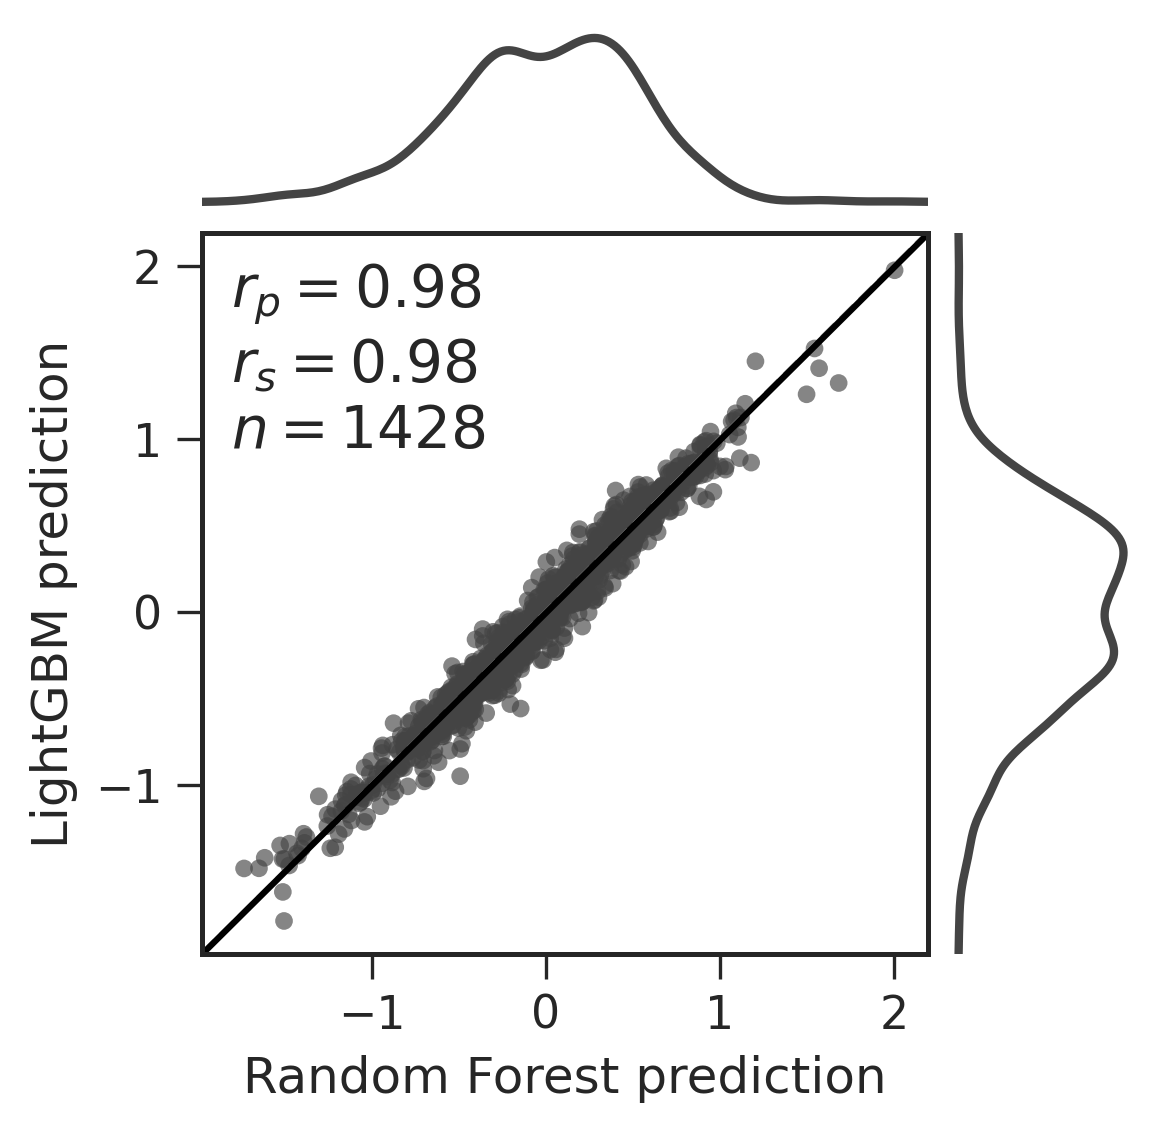

NB21 RF: (1076, 10) LGBM: (1076, 10)


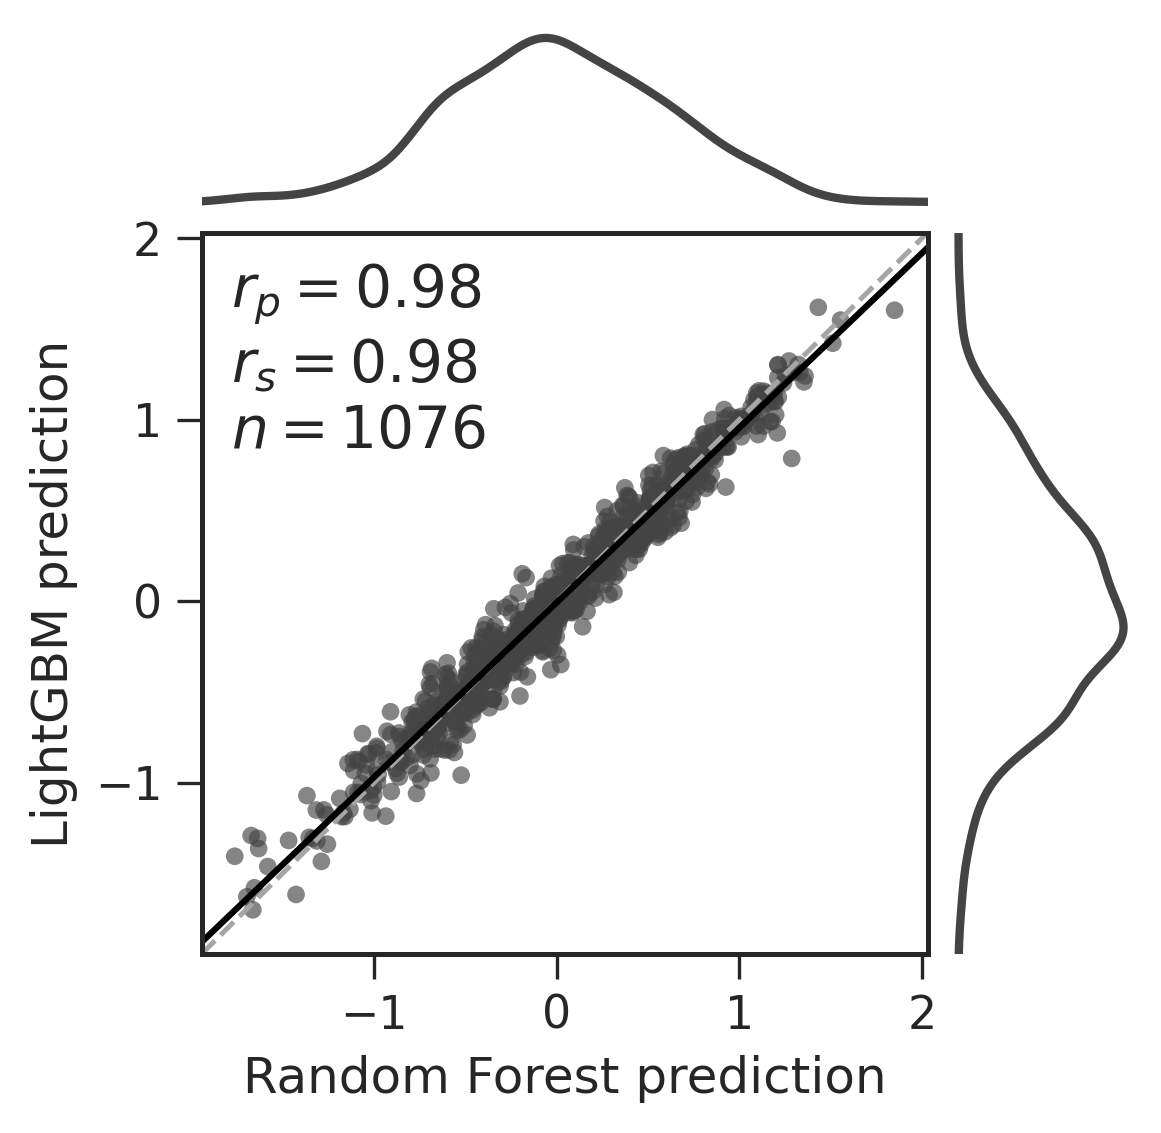

OS21 RF: (1107, 10) LGBM: (1107, 10)


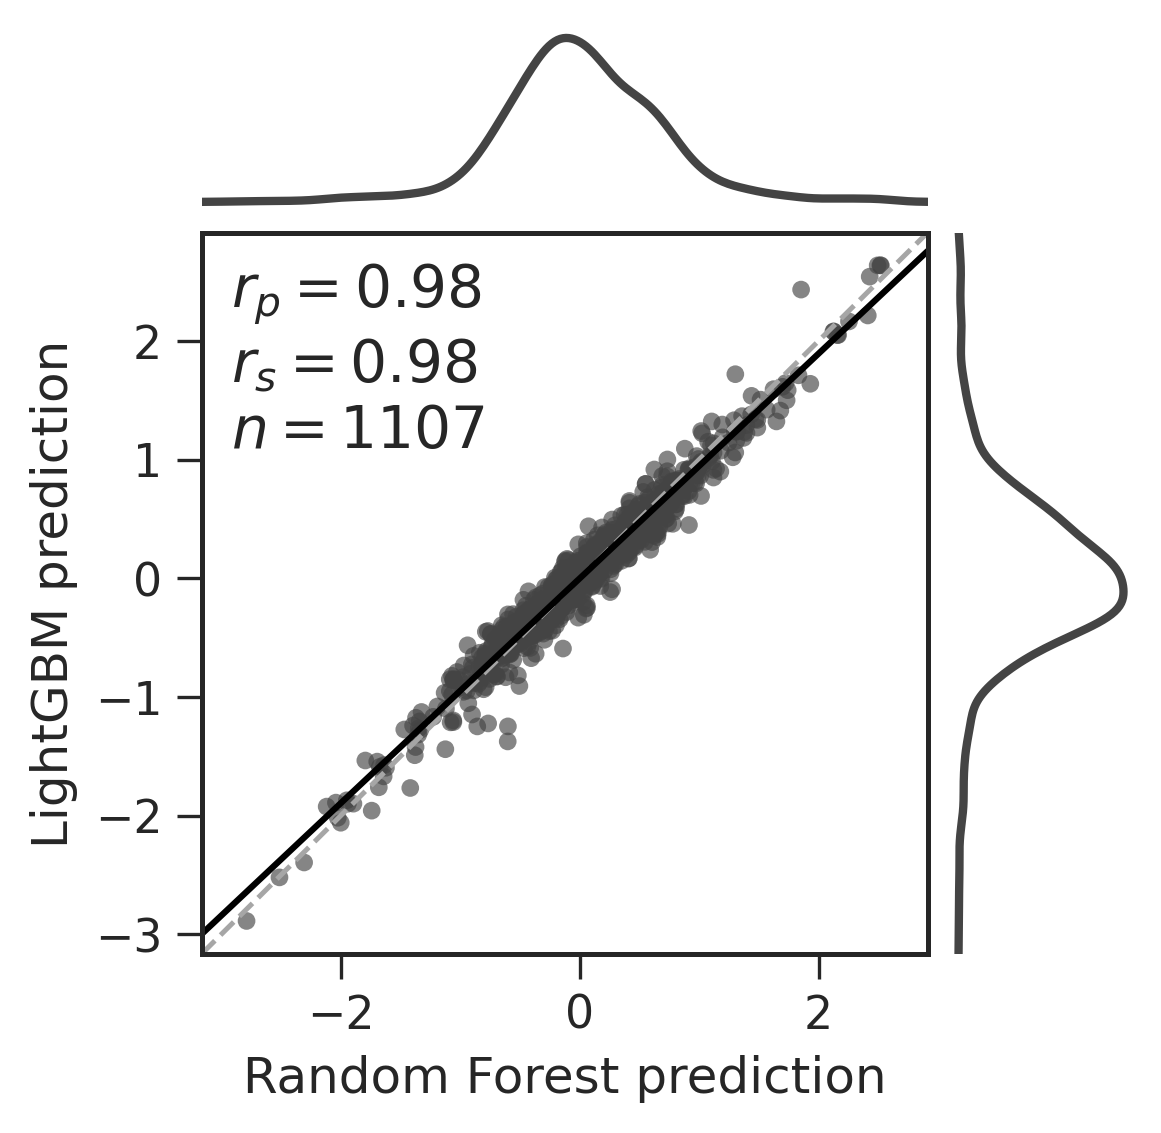

In [23]:
# ============================================
# RF vs LightGBM prediction comparison
# ============================================

for species in SPECIES_LIST:

    rf_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "RandomForest") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    lgbm_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "LightGBM") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    print(species, "RF:", rf_df.shape, "LGBM:", lgbm_df.shape)

    if rf_df.empty or lgbm_df.empty:
        print(f"{species}: missing prediction data.")
        continue

    fig, _ = joint_scatter(
        rf_df["predicted"],
        lgbm_df["predicted"],
        color="#444444",
        xlabel="Random Forest prediction",
        ylabel="LightGBM prediction",
        show_identity=True,
        show_regression=True,
        w=4,
        h=4,
    )

    plt.show()
    plt.close()

AT21 RF: (1428, 10) LGBM: (1428, 10)


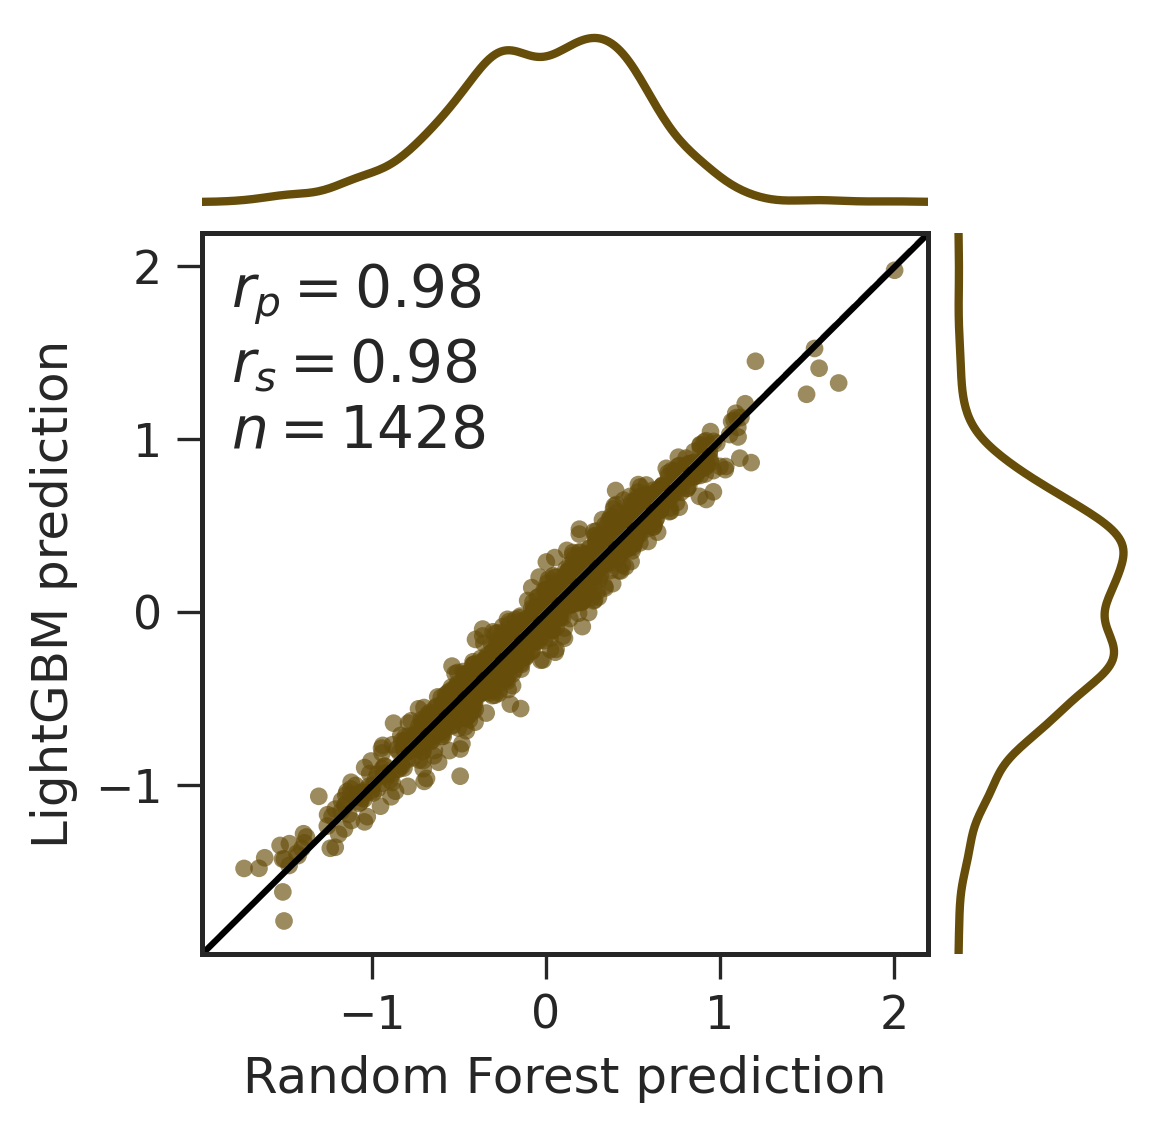

NB21 RF: (1076, 10) LGBM: (1076, 10)


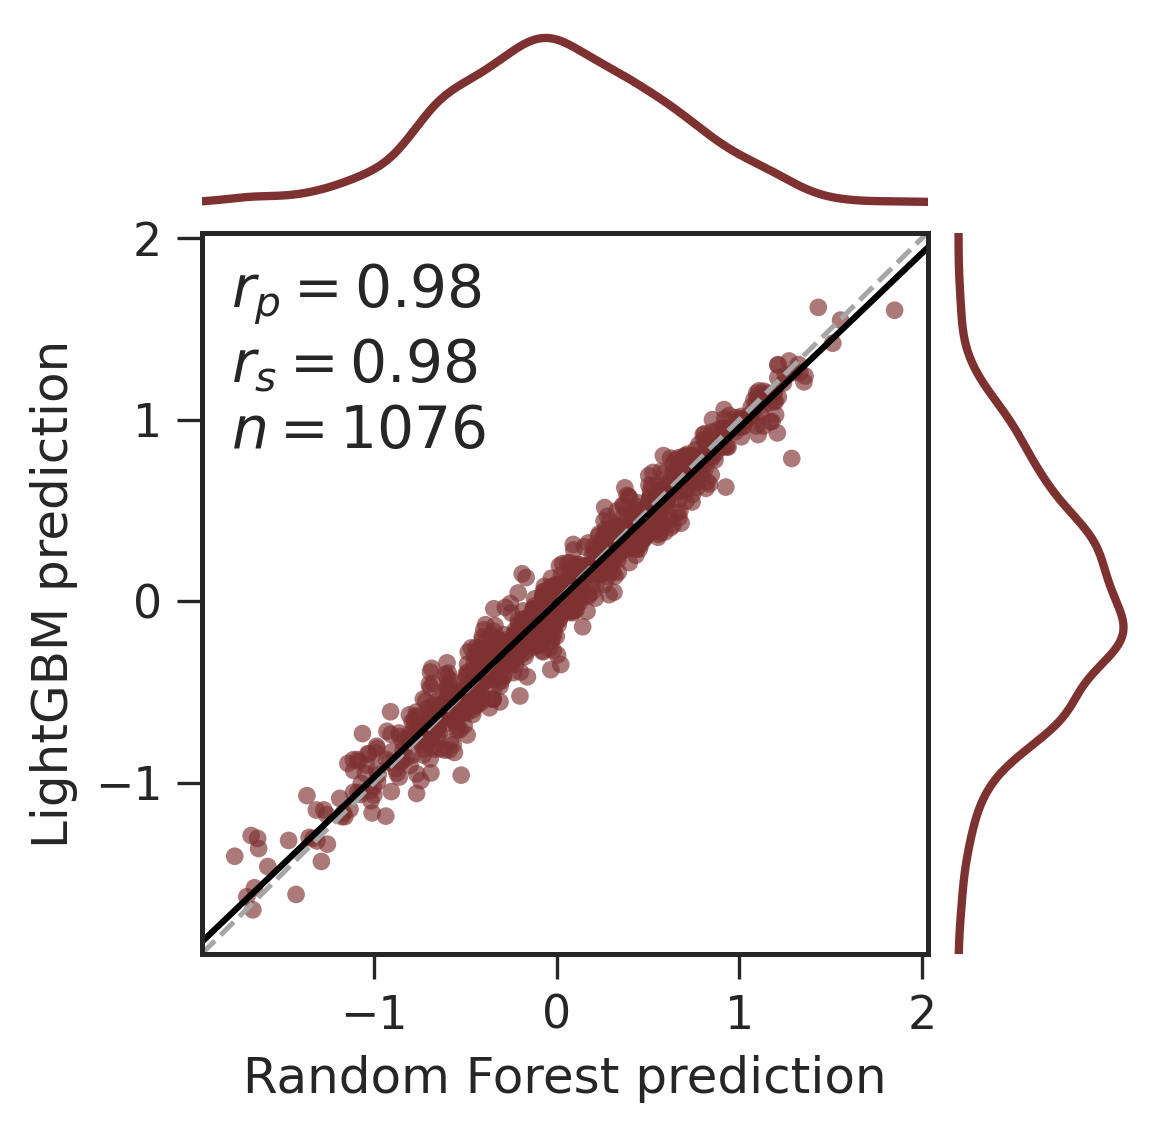

OS21 RF: (1107, 10) LGBM: (1107, 10)


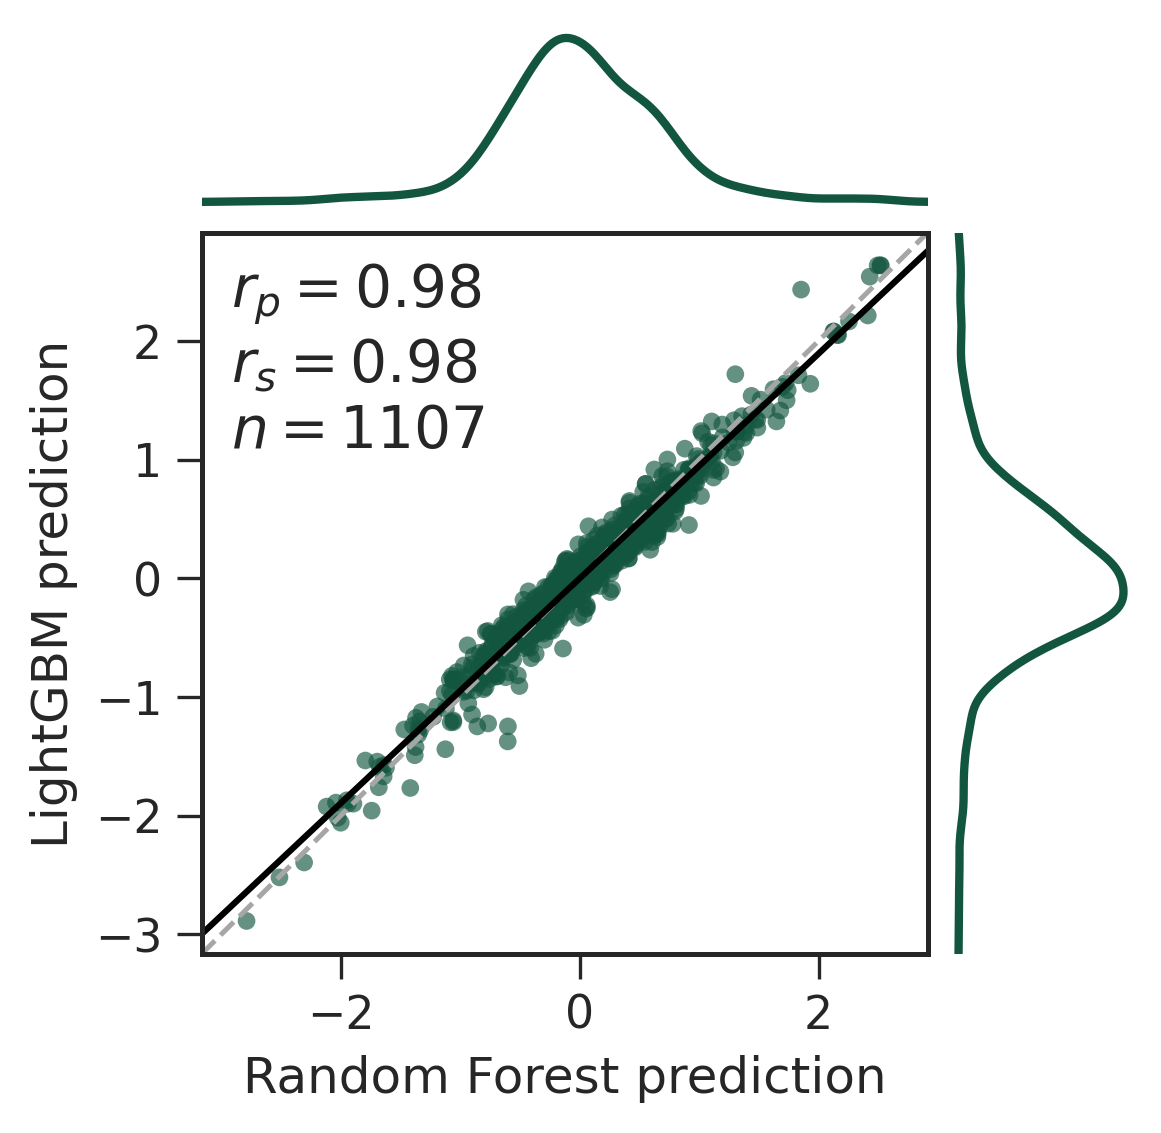

In [24]:
# ============================================
# RF vs LightGBM prediction comparison
# ============================================

for species in SPECIES_LIST:

    rf_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "RandomForest") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    lgbm_df = (
        prediction_df[
            (prediction_df["species"] == species) &
            (prediction_df["model"] == "LightGBM") &
            (prediction_df["dataset"] == "Test")
        ]
        .sort_values("var_id")
        .reset_index(drop=True)
    )

    print(species, "RF:", rf_df.shape, "LGBM:", lgbm_df.shape)

    if rf_df.empty or lgbm_df.empty:
        print(f"{species}: missing prediction data.")
        continue

    fig, _ = joint_scatter(
        rf_df["predicted"],
        lgbm_df["predicted"],
        color=SPECIES_INFO[species]["color"],
        xlabel="Random Forest prediction",
        ylabel="LightGBM prediction",
        # title=SPECIES_INFO[species]["label"],
        show_identity=True,
        show_regression=True,
        annotate=True,
        annotate_spearman=True,
        w=4,
        h=4,
    )

    plt.show()
    plt.close()

In [25]:
# ============================================
# Prepare feature importance analysis dataframe
# ============================================

feature_df = feature_importance_df.copy()

# Keep raw importance values from saved files.
# Recompute rank here so ranking method is explicit.
feature_df["rank_dense"] = (
    feature_df
    .groupby(["species", "model"])["importance"]
    .rank(
        ascending=False,
        method="dense",
    )
    .astype(int)
)

feature_df["rank_min"] = (
    feature_df
    .groupby(["species", "model"])["importance"]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

feature_df["importance_norm"] = (
    feature_df
    .groupby(["species", "model"])["importance"]
    .transform(lambda x: x / x.max())
)

feature_df = feature_df.sort_values(
    ["species", "model", "rank_dense"]
).reset_index(drop=True)

display(feature_df.head(20))

,species,model,rank,feature,importance,rank_dense,rank_min,importance_norm
0,AT21,LightGBM,1,3'UTR.UUU-freq,39.0,1,1,1.000000
1,AT21,LightGBM,2,5'UTR.C-freq,37.0,2,2,0.948718
2,AT21,LightGBM,3,5'UTR.S-freq,37.0,2,2,0.948718
3,AT21,LightGBM,4,5'UTR.CUU-freq,35.0,3,4,0.897436
4,AT21,LightGBM,5,5'UTR.MFE,34.0,4,5,0.871795
5,AT21,LightGBM,6,3'UTR.UAG-freq,32.0,5,6,0.820513
6,AT21,LightGBM,7,5'UTR.G-freq,32.0,5,6,0.820513
7,AT21,LightGBM,8,5'UTR.AC-freq,30.0,6,8,0.769231
8,AT21,LightGBM,9,CDS.U-freq,28.0,7,9,0.717949
9,AT21,LightGBM,10,5'UTR.AU-freq,28.0,7,9,0.717949


In [26]:
# ============================================
# RF vs LightGBM feature-importance rank agreement
# ============================================

def format_pvalue(pval):
    if np.isnan(pval):
        return "NA"
    if pval < 1e-4:
        return f"{pval:.1e}"
    return f"{pval:.4f}"


def plot_feature_rank_agreement(
    feature_importance_df,
    *,
    species,
    w=4.0,
    h=4.0,
    color=None,
):
    df = feature_importance_df.copy()

    if color is None:
        color = SPECIES_INFO[species]["color"]

    rf = df[
        (df["species"] == species)
        & (df["model"] == "RandomForest")
    ][["feature", "rank"]].rename(
        columns={"rank": "RF_rank"}
    )

    lgbm = df[
        (df["species"] == species)
        & (df["model"] == "LightGBM")
    ][["feature", "rank"]].rename(
        columns={"rank": "LGBM_rank"}
    )

    rank_df = rf.merge(
        lgbm,
        on="feature",
        how="inner",
    )

    fig, ax = make_fig(w=w, h=h)

    ax.scatter(
        rank_df["RF_rank"],
        rank_df["LGBM_rank"],
        s=18,
        alpha=0.55,
        edgecolor="none",
        color=color,
    )

    max_rank = int(
        max(
            rank_df["RF_rank"].max(),
            rank_df["LGBM_rank"].max(),
        )
    )

    ax.plot(
        [0, max_rank],
        [0, max_rank],
        ls="--",
        lw=1.2,
        color="0.65",
        zorder=1,
    )

    ax.set_xlim(max_rank + 5, 0)
    ax.set_ylim(max_rank + 5, 0)

    format_axis(
        ax,
        xlabel="RF rank",
        ylabel="LightGBM rank",
        compact_ticks=(),
    )

    rho, pval = safe_spearmanr(
        rank_df["RF_rank"],
        rank_df["LGBM_rank"],
    )

    ax.text(
        0.05,
        0.95,
        rf"$\rho = {rho:.2f}$"
        + "\n"
        + rf"$P = {format_pvalue(pval)}$"
        + "\n"
        + f"$n = {len(rank_df)}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
    )

    ax.set_title(SPECIES_INFO[species]["label"])

    plt.tight_layout()
    plt.show()
    plt.close()

    return fig, rank_df

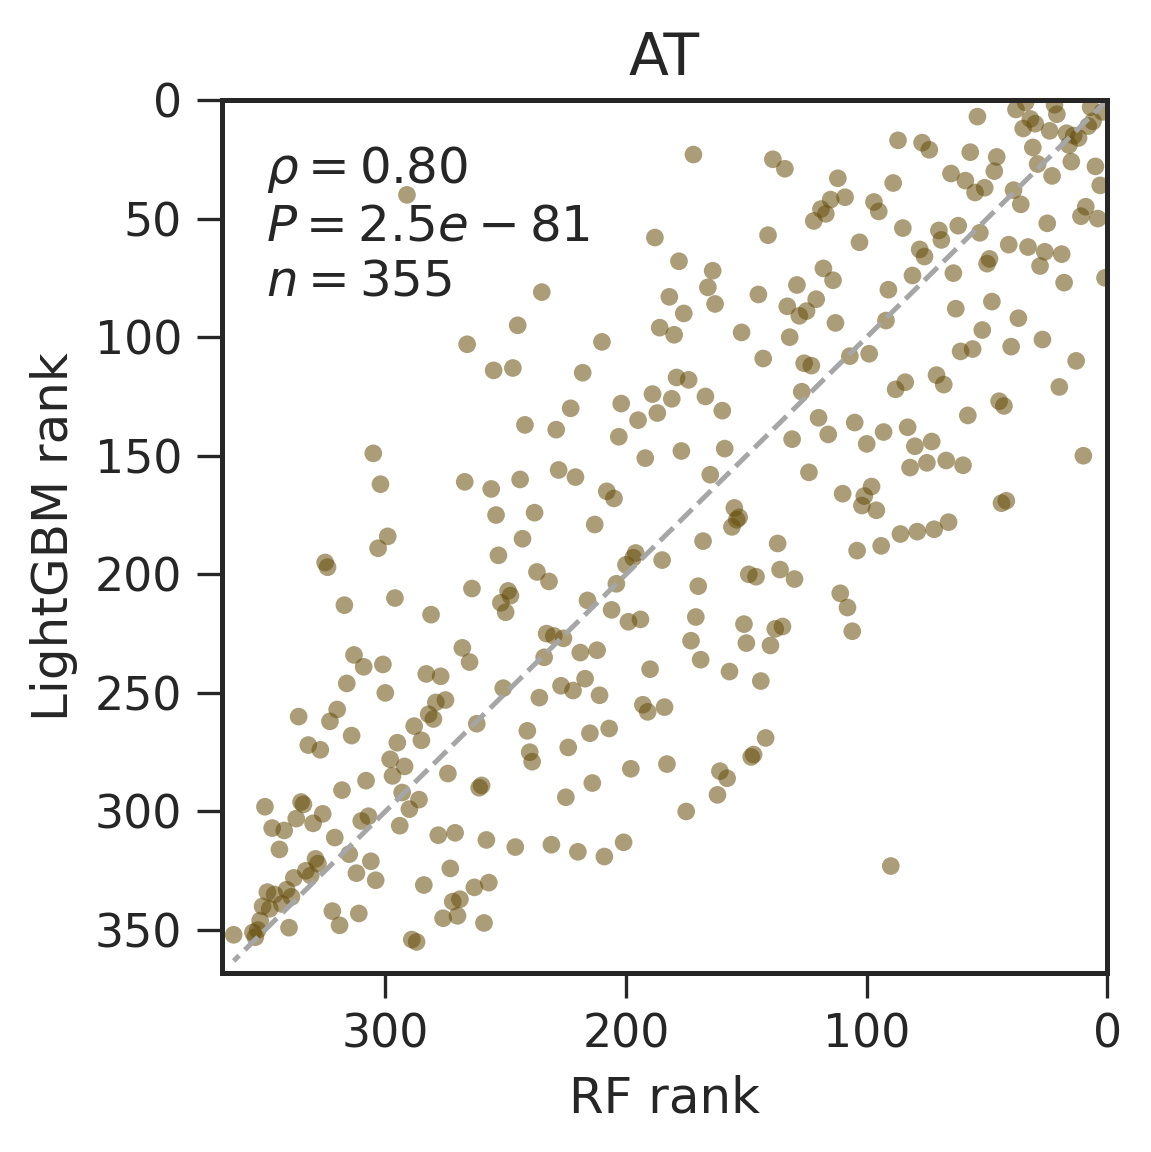

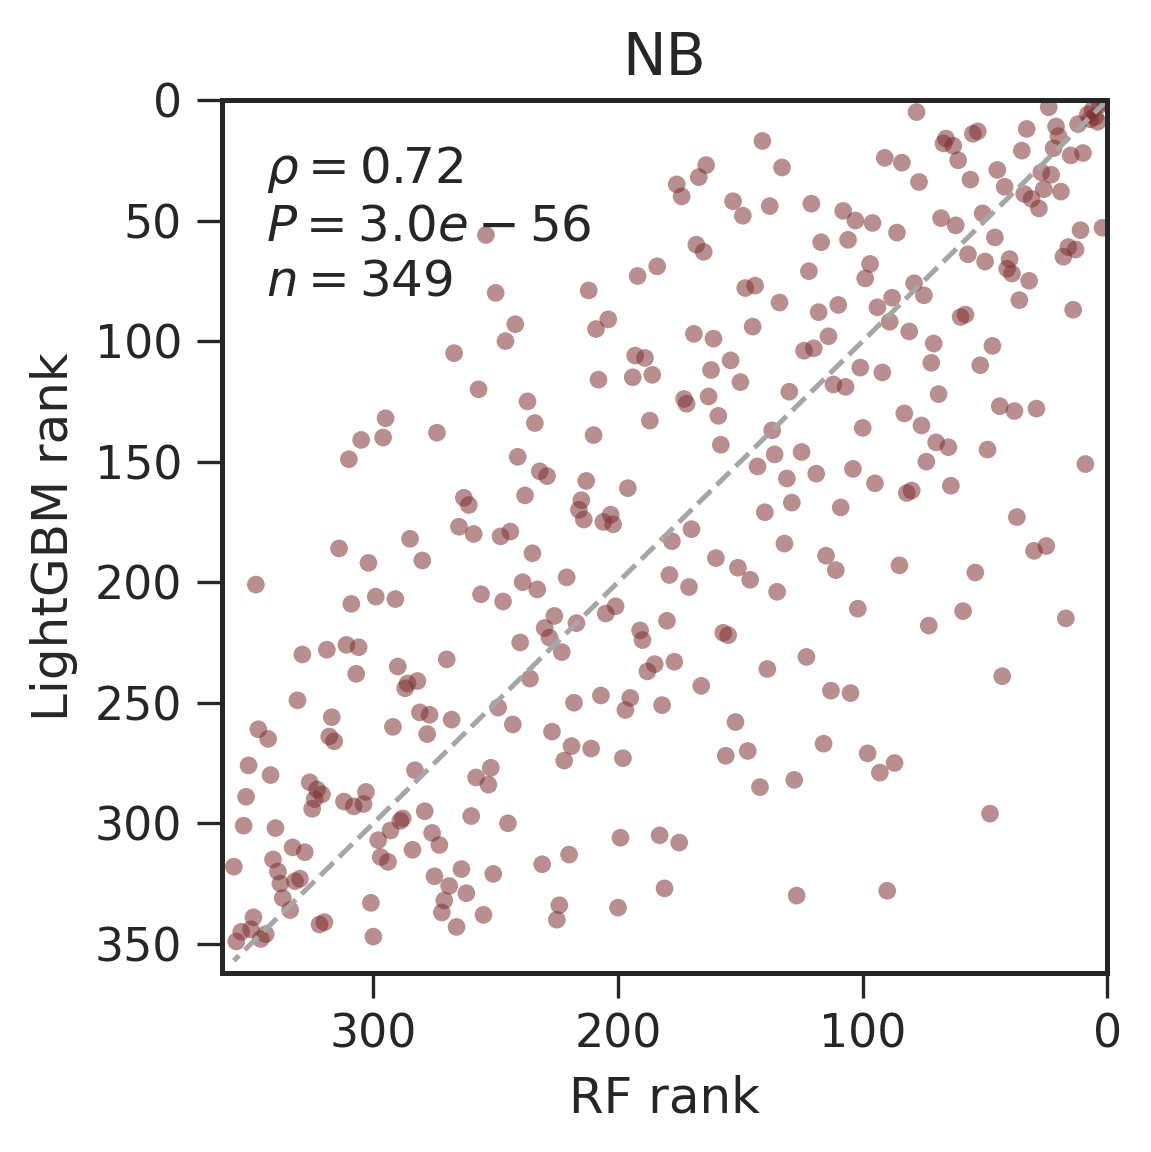

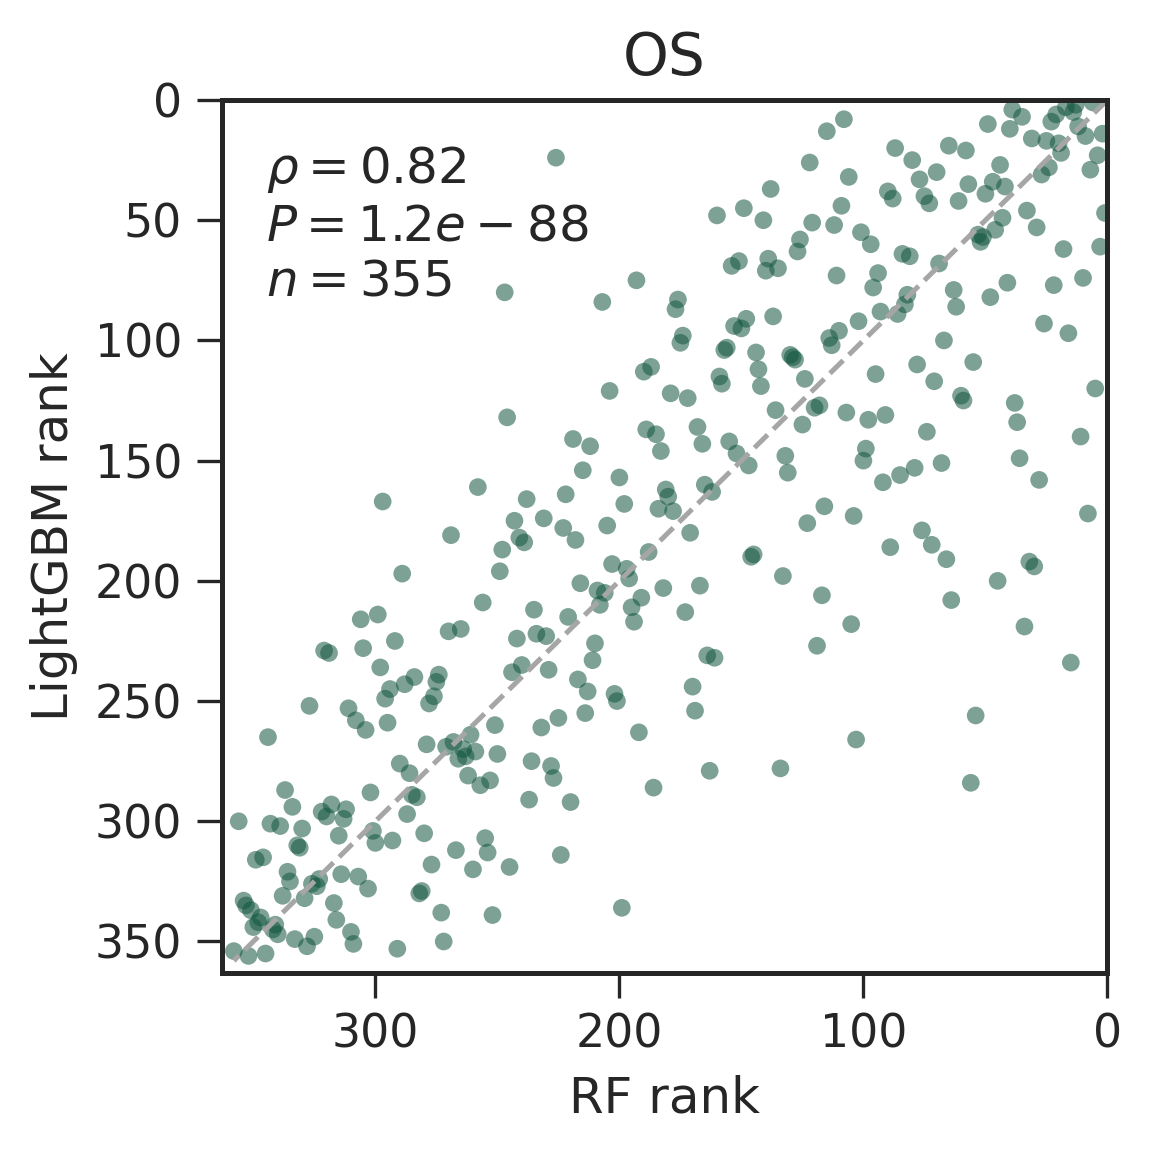

In [27]:
# ============================================
# Run feature-importance rank agreement plots
# ============================================

rank_agreement_tables = {}

for species in SPECIES_LIST:
    fig, rank_df = plot_feature_rank_agreement(
        feature_df,
        species=species,
        w=4.0,
        h=4.0,
    )

    rank_agreement_tables[species] = rank_df

In [28]:
# ============================================
# Transform feature importance
# ============================================

from sklearn.preprocessing import PowerTransformer

feature_norm_df = feature_df.copy()

feature_norm_df["importance_yj"] = np.nan
feature_norm_df["importance_z"] = np.nan

for (species, model), idx in feature_norm_df.groupby(
    ["species", "model"]
).groups.items():

    values = feature_norm_df.loc[idx, "importance"].to_numpy().reshape(-1, 1)

    pt = PowerTransformer(
        method="yeo-johnson",
        standardize=False,
    )

    yj = pt.fit_transform(values).ravel()

    z = (yj - yj.mean()) / yj.std(ddof=0)

    feature_norm_df.loc[idx, "importance_yj"] = yj
    feature_norm_df.loc[idx, "importance_z"] = z

display(feature_norm_df.head())

,species,model,rank,feature,importance,rank_dense,rank_min,importance_norm,importance_yj,importance_z
0,AT21,LightGBM,1,3'UTR.UUU-freq,39.0,1,1,1.000000,7.848084,2.686936
1,AT21,LightGBM,2,5'UTR.C-freq,37.0,2,2,0.948718,7.650424,2.547411
2,AT21,LightGBM,3,5'UTR.S-freq,37.0,2,2,0.948718,7.650424,2.547411
3,AT21,LightGBM,4,5'UTR.CUU-freq,35.0,3,4,0.897436,7.446078,2.403167
4,AT21,LightGBM,5,5'UTR.MFE,34.0,4,5,0.871795,7.341207,2.329141


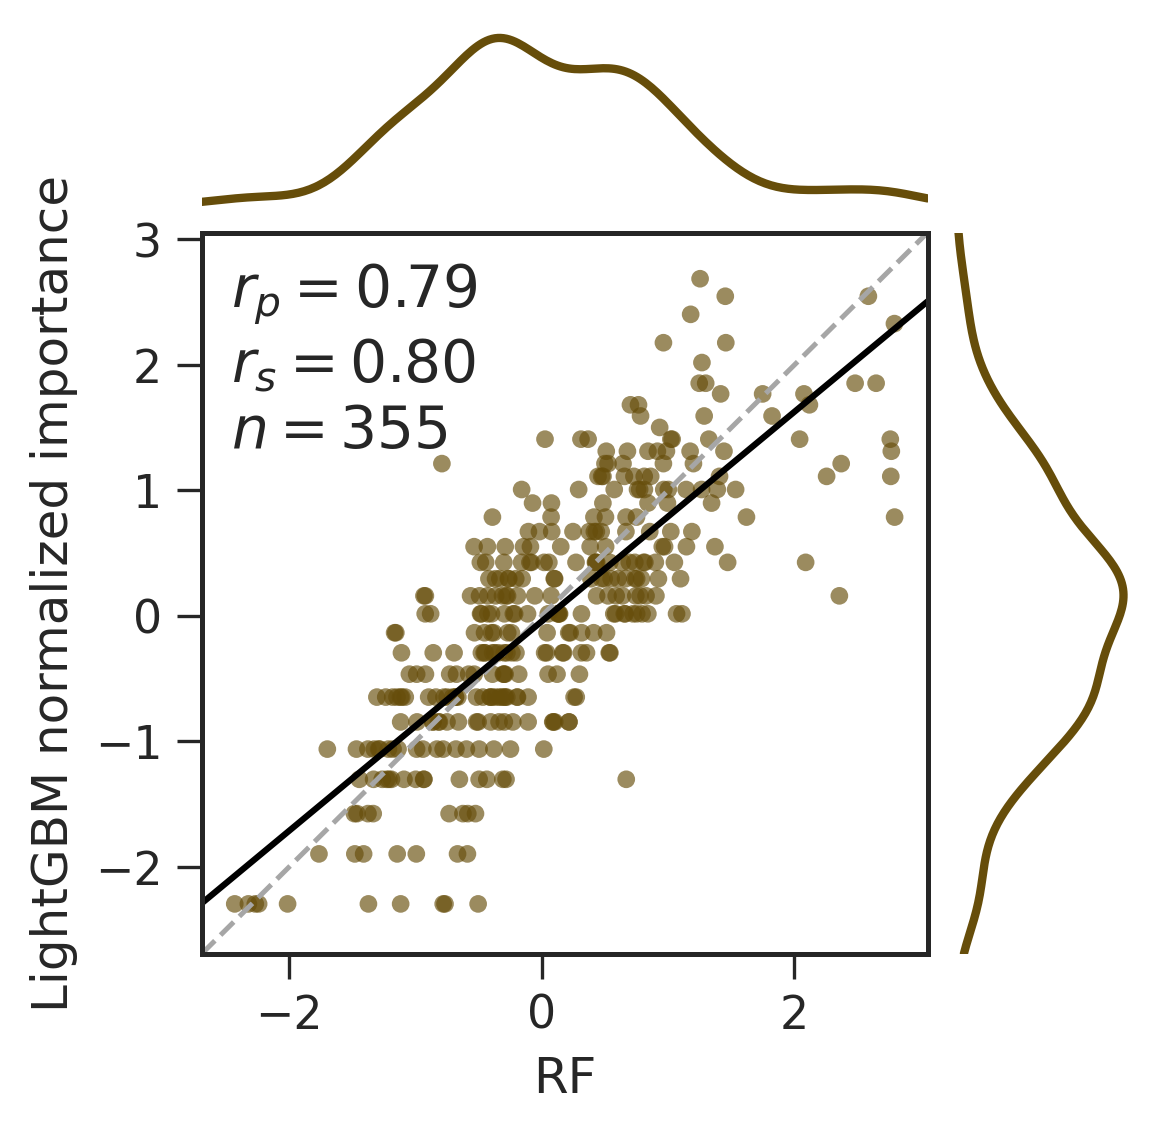

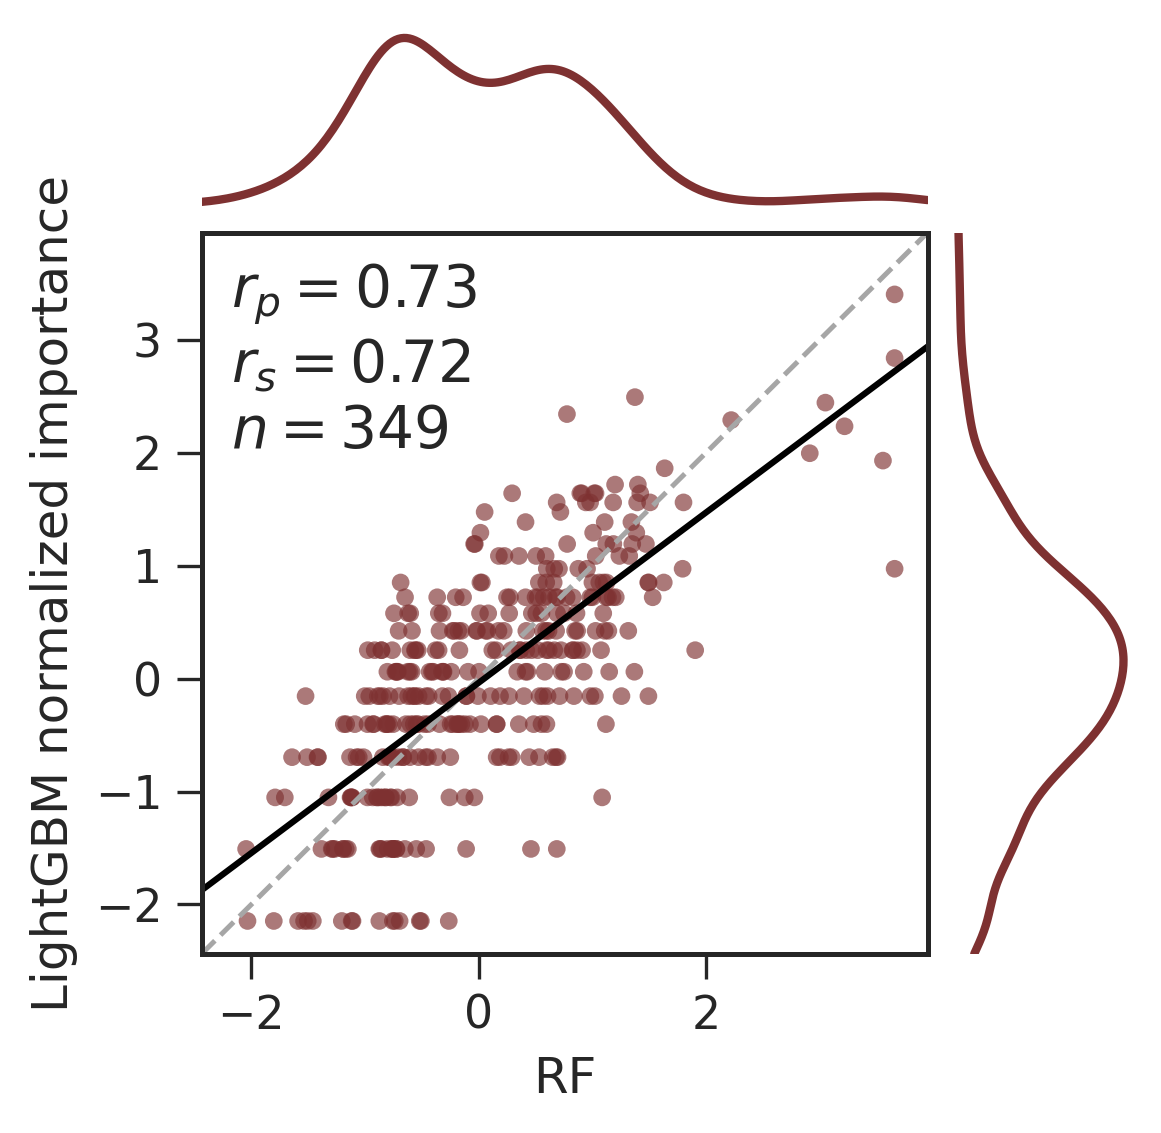

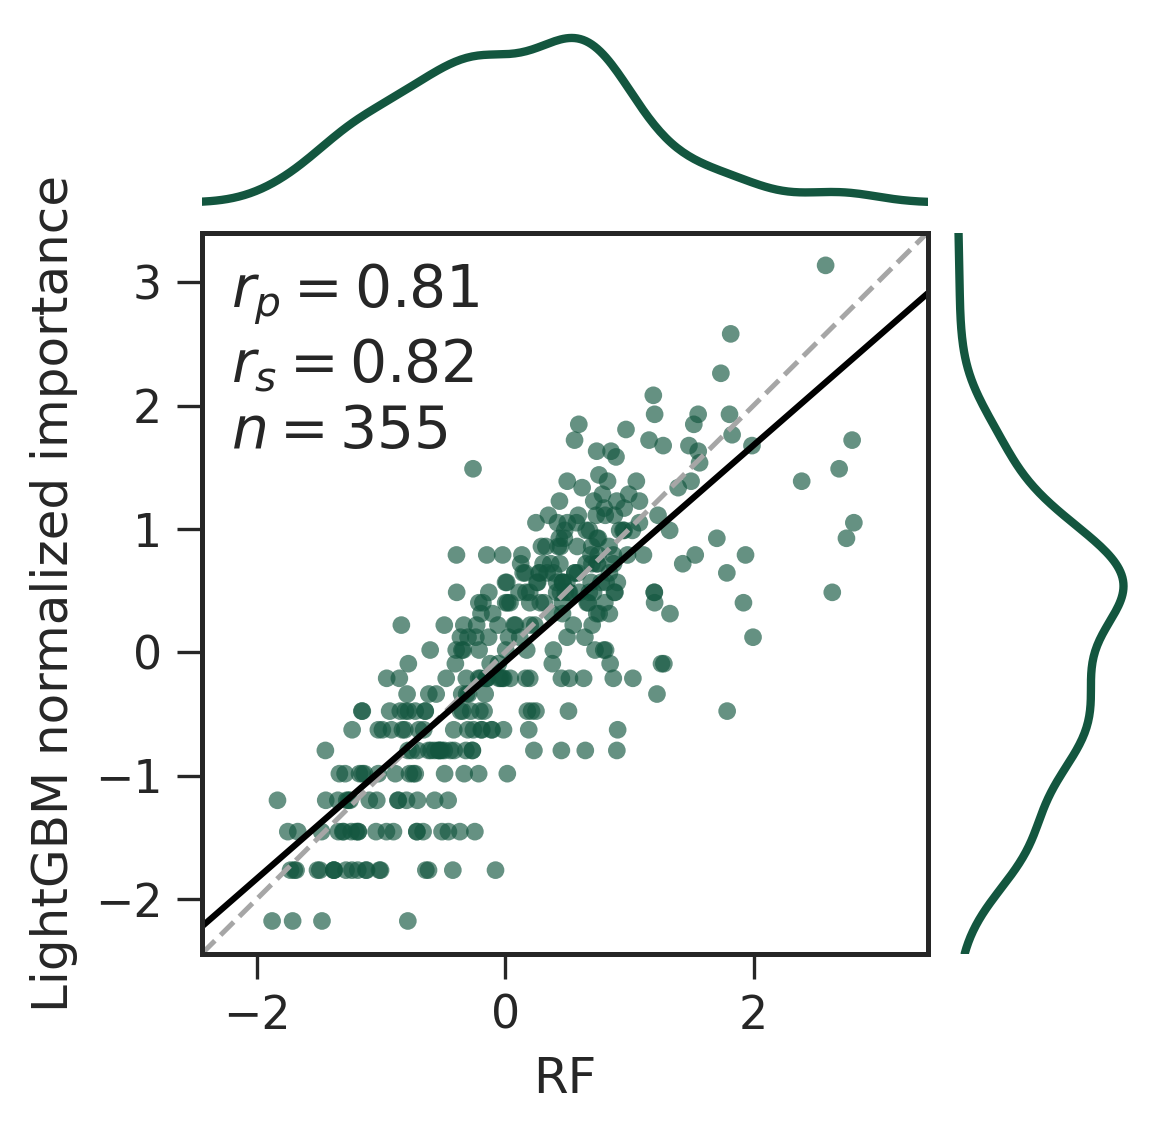

In [29]:
# ============================================
# RF vs LightGBM normalized importance
# ============================================

for species in SPECIES_LIST:

    rf = (
        feature_norm_df[
            (feature_norm_df["species"] == species)
            & (feature_norm_df["model"] == "RandomForest")
        ][["feature", "importance_z"]]
        .rename(columns={"importance_z": "RF"})
    )

    lgbm = (
        feature_norm_df[
            (feature_norm_df["species"] == species)
            & (feature_norm_df["model"] == "LightGBM")
        ][["feature", "importance_z"]]
        .rename(columns={"importance_z": "LightGBM"})
    )

    plot_df = rf.merge(
        lgbm,
        on="feature",
        how="inner",
    )

    fig, _ = joint_scatter(
        plot_df["RF"],
        plot_df["LightGBM"],
        color=SPECIES_INFO[species]["color"],
        xlabel="RF",
        ylabel="LightGBM normalized importance",
        # title=SPECIES_INFO[species]["label"],
        show_identity=True,
        show_regression=True,
        annotate=True,
        annotate_spearman=True,
        w=4,
        h=4,
    )

    plt.show()
    plt.close()

In [31]:
# ============================================
# Prepare region CV data for grouped species plot
# ============================================

def parse_sets(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return []


region_lgbm_df = cv_region_df[
    cv_region_df["model"] == "LightGBM"
].copy()

region_lgbm_df["sets"] = region_lgbm_df["sets"].apply(parse_sets)

region_lgbm_df["combo_label"] = region_lgbm_df["sets"].apply(
    lambda xs: " + ".join(xs)
)

region_lgbm_df = region_lgbm_df.sort_values(
    ["n_sets", "combo_label", "species"]
).reset_index(drop=True)

display(region_lgbm_df.head())

,species,model,grouping,combo,sets,mean_R2,std_R2,n_sets,n_features,combo_label
0,AT21,LightGBM,region,3'UTR,[3'UTR],0.178088,0.024436,1,92,3'UTR
1,NB21,LightGBM,region,3'UTR,[3'UTR],0.189020,0.022052,1,92,3'UTR
2,OS21,LightGBM,region,3'UTR,[3'UTR],0.266880,0.035325,1,92,3'UTR
3,AT21,LightGBM,region,5'UTR,[5'UTR],0.214914,0.028876,1,93,5'UTR
4,NB21,LightGBM,region,5'UTR,[5'UTR],0.258764,0.024680,1,93,5'UTR


In [32]:
# ============================================
# LGBM region contribution: species grouped bars
# ============================================

def plot_region_grouped_species(
    df,
    *,
    title="LightGBM regions",
    w=10,
    h=4.5,
):
    plot_df = df.copy()

    combo_order = (
        plot_df[["combo_label", "n_sets"]]
        .drop_duplicates()
        .sort_values(["n_sets", "combo_label"])
        ["combo_label"]
        .tolist()
    )

    species_order = list(SPECIES_INFO.keys())

    x = np.arange(len(combo_order))
    bar_w = 0.24

    fig, ax = make_fig(w=w, h=h)

    for i, species in enumerate(species_order):
        sub = (
            plot_df[plot_df["species"] == species]
            .set_index("combo_label")
            .reindex(combo_order)
            .reset_index()
        )

        ax.bar(
            x + (i - 1) * bar_w,
            sub["mean_R2"],
            width=bar_w,
            color=SPECIES_INFO[species]["color"],
            label=SPECIES_INFO[species]["short"],
            edgecolor="none",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(combo_order, rotation=45, ha="right")

    format_axis(
        ax,
        xlabel=None,
        ylabel="Mean $R^2$ (CV)",
        compact_ticks=(),
    )

    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

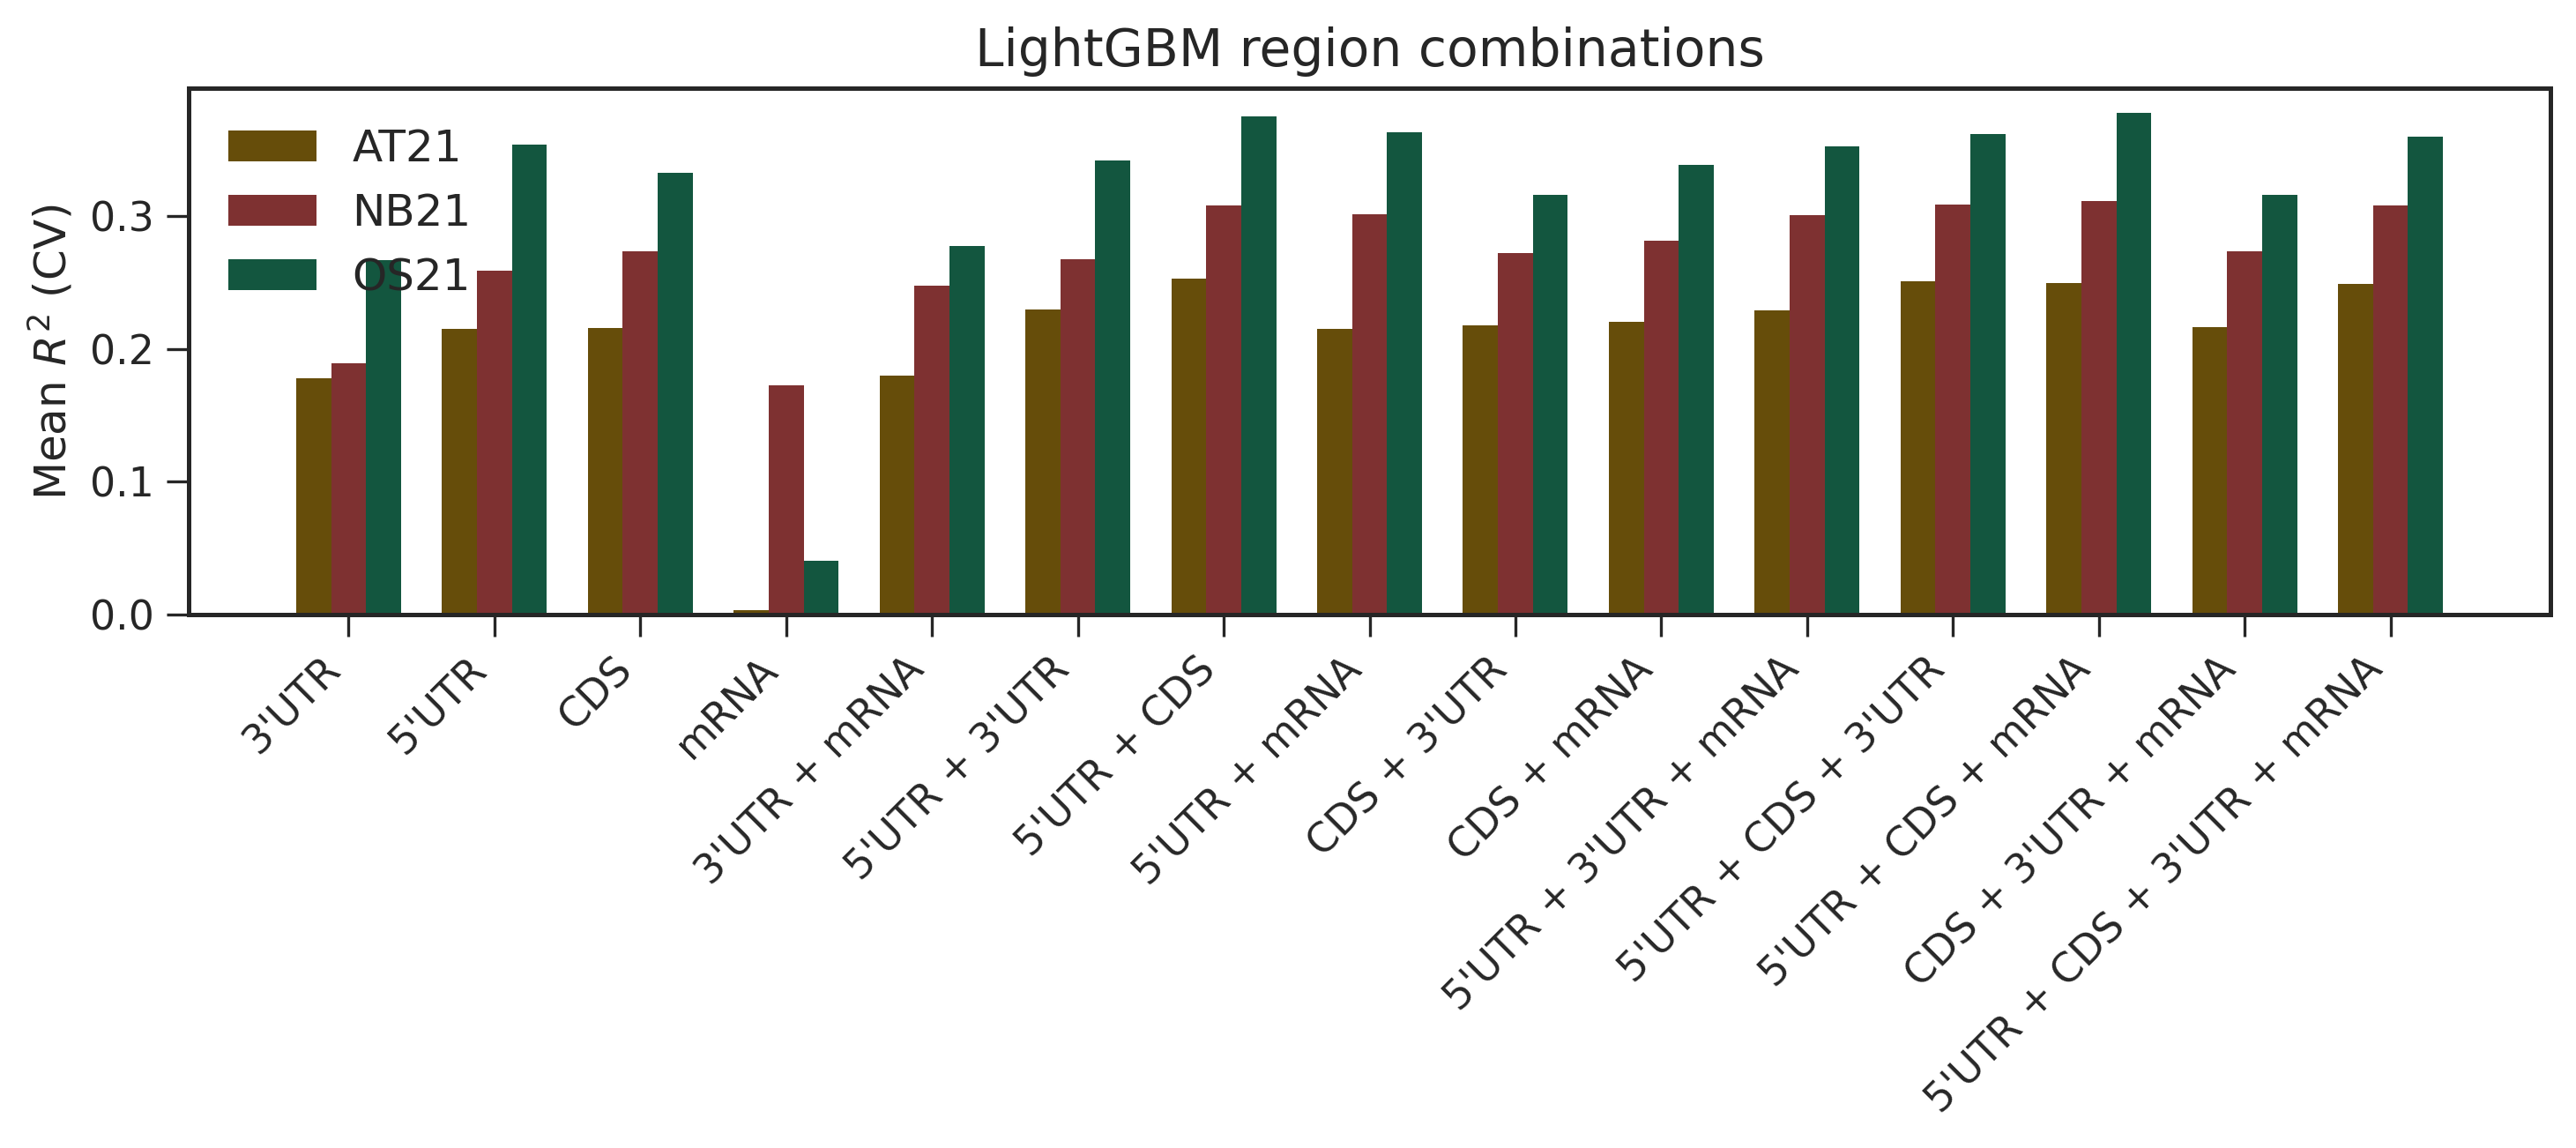

In [33]:
fig = plot_region_grouped_species(
    region_lgbm_df,
    title="LightGBM region combinations",
    w=10,
    h=4.5,
)

In [51]:
# ============================================
# UpSet-style plot with species-grouped mean ± SD boxes
# ============================================

import ast
import itertools


def parse_sets(x):
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        return ast.literal_eval(x)
    return []


def combo_label(combo):
    return "\n+\n".join(combo)


def plot_upset_species_boxes(
    cv_df,
    *,
    model="LightGBM",
    selected_groups=("mRNA", "CDS", "5'UTR", "3'UTR"),
    title=None,
    w=11,
    h=5.5,
    set_width=1.25,
    matrix_width=5.5,
    top_height=3.2,
    matrix_height=1.35,
    box_width=0.18,
):
    df = cv_df.copy()
    df = df[df["model"] == model].copy()

    df["sets"] = df["sets"].apply(parse_sets)
    selected_groups = list(selected_groups)

    df["combo_key"] = df["sets"].apply(
        lambda xs: tuple(g for g in selected_groups if g in xs)
    )

    combo_order = []
    for k in range(1, len(selected_groups) + 1):
        combo_order.extend(itertools.combinations(selected_groups, k))

    present_combos = set(df["combo_key"])
    combo_order = [c for c in combo_order if c in present_combos]

    species_order = list(SPECIES_INFO.keys())

    x = np.arange(len(combo_order))
    y = np.arange(len(selected_groups))

    set_size_dict = {}
    for group in selected_groups:
        sub = df[df["combo_key"].apply(lambda z: z == (group,))]
        set_size_dict[group] = int(sub["n_features"].max()) if len(sub) else np.nan

    set_sizes = [set_size_dict[g] for g in selected_groups]

    fig = plt.figure(figsize=(w, h), dpi=_PLOT_CFG["dpi"])

    gs = fig.add_gridspec(
        2,
        2,
        width_ratios=[set_width, matrix_width],
        height_ratios=[top_height, matrix_height],
        wspace=0.03,
        hspace=0.03,
    )

    ax_empty = fig.add_subplot(gs[0, 0])
    ax_top = fig.add_subplot(gs[0, 1])
    ax_set = fig.add_subplot(gs[1, 0])
    ax_mat = fig.add_subplot(gs[1, 1], sharex=ax_top)

    ax_empty.axis("off")

    # ========================================
    # Top panel: mean ± SD boxes
    # ========================================

    offsets = np.linspace(
        -box_width * 1.4,
        box_width * 1.4,
        len(species_order),
    )

    for i, species in enumerate(species_order):
        color = SPECIES_INFO[species]["color"]

        for j, combo in enumerate(combo_order):
            sub = df[
                (df["species"] == species)
                & (df["combo_key"] == combo)
            ]

            if len(sub) == 0:
                continue

            mean = float(sub["mean_R2"].iloc[0])
            sd = float(sub["std_R2"].iloc[0]) if "std_R2" in sub.columns else 0.0

            xpos = x[j] + offsets[i]

            # SD interval as rectangle
            ax_top.add_patch(
                mpl.patches.Rectangle(
                    (xpos - box_width / 2, mean - sd),
                    box_width,
                    2 * sd,
                    facecolor=color,
                    edgecolor="black",
                    linewidth=0.6,
                    alpha=0.95,
                )
            )

            # mean line
            ax_top.plot(
                [xpos - box_width / 2, xpos + box_width / 2],
                [mean, mean],
                color="black",
                lw=1.0,
            )

    for species in species_order:
        ax_top.bar(
            [],
            [],
            color=SPECIES_INFO[species]["color"],
            label=SPECIES_INFO[species]["short"],
        )

    ax_top.set_ylabel("Mean $R^2$ (CV)")
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(
        [combo_label(c) for c in combo_order],
        fontsize=8,
    )
    ax_top.tick_params(axis="x", length=0, pad=4)

    ax_top.legend(
        frameon=False,
        ncol=len(species_order),
        loc="upper left",
    )

    if title is not None:
        ax_top.set_title(title)

    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)

    # ========================================
    # Left panel: set size
    # ========================================

    ax_set.barh(
        y,
        set_sizes,
        color="0.25",
        edgecolor="none",
    )

    ax_set.set_yticks(y)
    ax_set.set_yticklabels(selected_groups)

    ax_set.invert_yaxis()
    ax_set.invert_xaxis()

    ax_set.tick_params(axis="x", bottom=False, labelbottom=False)
    ax_set.set_xlabel("")
    ax_set.set_ylabel("")

    ax_set.spines["top"].set_visible(False)
    ax_set.spines["right"].set_visible(False)
    ax_set.spines["bottom"].set_visible(False)

    # ========================================
    # Matrix panel
    # ========================================

    for j, group in enumerate(selected_groups):
        ax_mat.scatter(
            x,
            np.repeat(j, len(combo_order)),
            s=90,
            color="0.82",
            edgecolor="none",
            zorder=1,
        )

    for i, combo in enumerate(combo_order):
        active = [
            j for j, group in enumerate(selected_groups)
            if group in combo
        ]

        ax_mat.scatter(
            np.repeat(i, len(active)),
            active,
            s=105,
            color="black",
            edgecolor="none",
            zorder=3,
        )

        if len(active) > 1:
            ax_mat.plot(
                [i, i],
                [min(active), max(active)],
                color="black",
                lw=2,
                zorder=2,
            )

    ax_mat.set_yticks(y)
    ax_mat.set_yticklabels([])
    ax_mat.set_xticks([])
    ax_mat.set_xlim(-0.5, len(combo_order) - 0.5)
    ax_mat.invert_yaxis()

    ax_mat.spines["top"].set_visible(False)
    ax_mat.spines["right"].set_visible(False)
    ax_mat.spines["bottom"].set_visible(False)

    plt.tight_layout()
    plt.show()
    plt.close()

    return fig

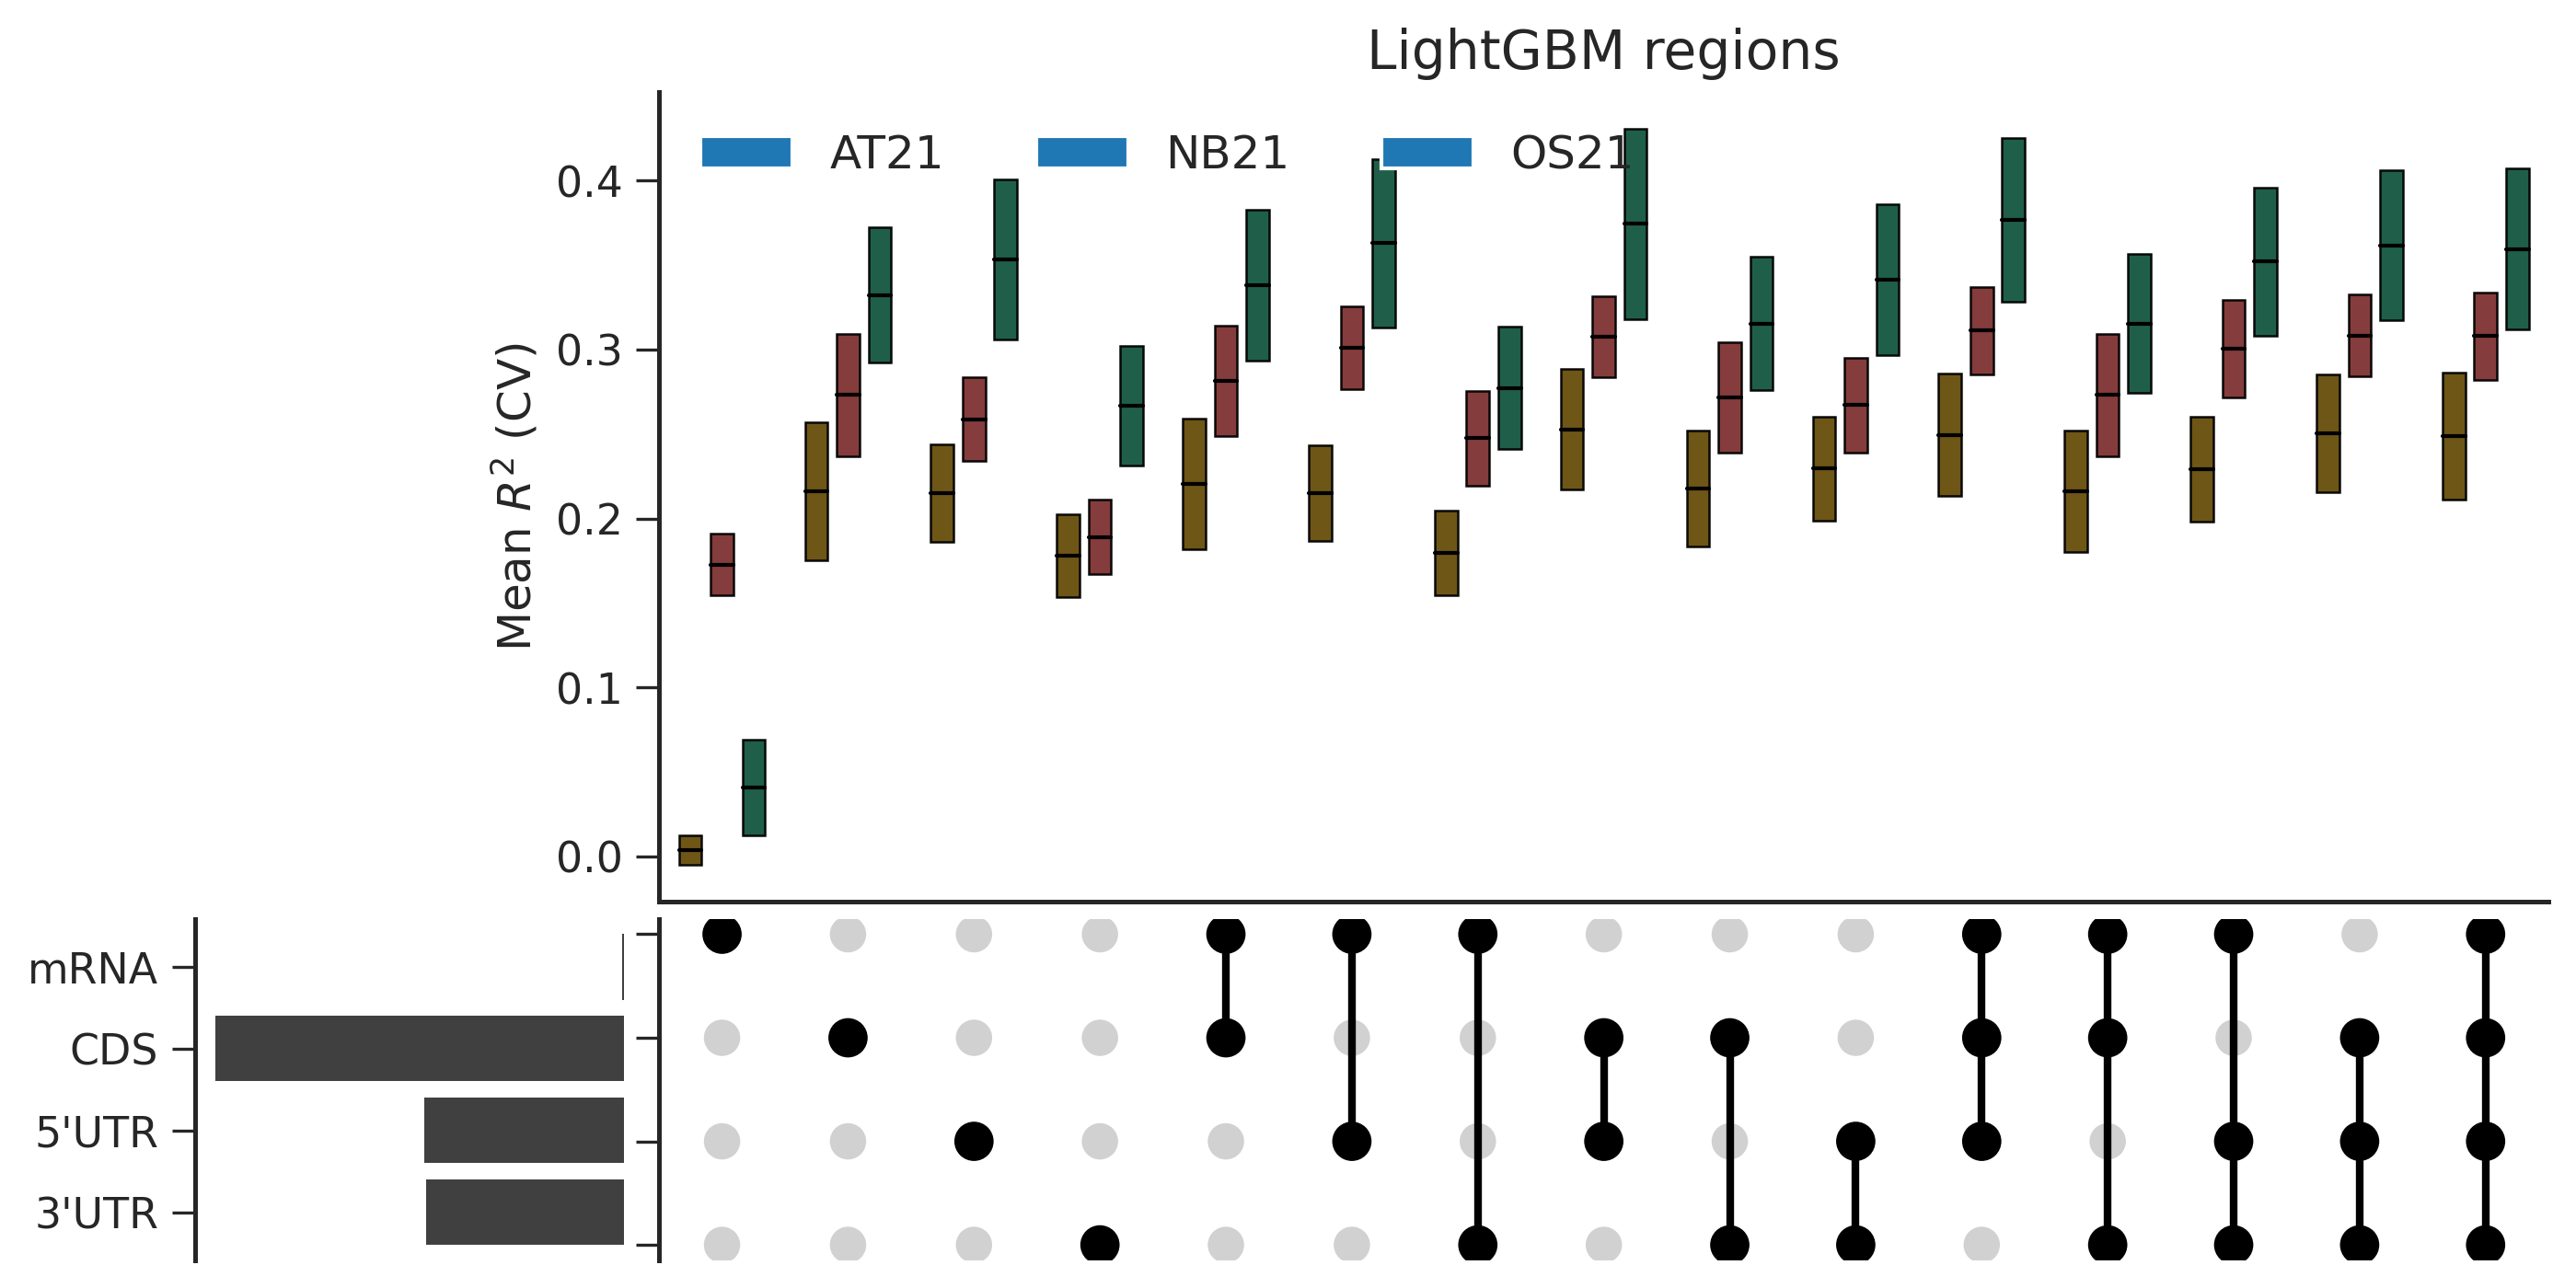

In [52]:
fig = plot_upset_species_boxes(
    cv_region_df,
    model="LightGBM",
    selected_groups=("mRNA", "CDS", "5'UTR", "3'UTR"),
    title="LightGBM regions",
    w=11,
    h=5.5,
)